<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/A_B%20Testing%20Series/AB_test_AI_impact_2024_vs_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='3386FF'>A/B-сравнение: рынок вакансий аналитиков, март 2024 vs март 2026</font>
### <font color='7A7A7A'>Гипотеза: как на рынок повлияло распространение AI-инструментов</font>

### <font color='7A7A7A'>Технический источник данных и ⚠️ важное предупреждение</font>

Сравниваются две **однонедельные** выборки того же парсера HH.ru:

* **Группа A** — `hh_2024-03-07.csv`, 28.02–07.03.2024;
* **Группа B** — `hh_2026-03-21.csv`, 13.03–21.03.2026.

В отличие от предыдущих тетрадей серии (сравнение недель/месяцев 2023 года), здесь есть несколько дополнительных источников шума, которые нужно держать в голове при чтении выводов:

1. **Разрыв в два года** — за это время на рынке могло произойти что угодно: инфляция, макроэкономика, сезонность конкретного марта, изменения самой HH-платформы — не только внедрение AI. Эта тетрадь может показать *корреляции*, а не доказать, что причина именно в AI.
2. **У парсера изменилась схема данных.** Файл 2026 года содержит другой набор столбцов:

| | 2024 (группа A) | 2026 (группа B) |
|---|---|---|
| Зарплата | одна строка `salary` вида `'100000.0-150000.0 RUR'` | раздельные `salary_from` / `salary_to`, **без валюты** |
| Страна/формат | `country` (везде "Россия", поле неинформативно) | `format` — новое поле: офис/удалёнка/гибрид/сменный график |
| `skills` | всегда пусто | заполнено почти всегда — короткий сниппет с подсветкой совпадений `<highlighttext>` |
| `job_type` | включает категорию "Стажировка" | категории "Стажировка" в данных нет вообще (см. раздел 5) |

Это значит: часть метрик несопоставима напрямую (формат удалёнки — новое поле, зарплату надо парсить по-разному), а часть требует дополнительной проверки, прежде чем доверять расхождению (пропала ли "Стажировка" как категория вакансий или просто исчезла как ярлык в интерфейсе HH).
3. **Объём выборки drastически отличается**: после дедупликации в группе A — 1891 уникальная вакансия, в группе B — только 789 (в 2.4 раза меньше). Это, вероятнее всего, отражает более узкий охват парсинга в 2026 году (другой набор поисковых запросов/меньше страниц выдачи), а не то, что вакансий аналитиков в 2.4 раза меньше — этот вывод делать нельзя. Поэтому все дальнейшие сравнения — **по долям и частотам**, а не по абсолютным числам.
4. **Поле `description` крайне разрежено в обоих срезах** (у нас нет соседних перекрывающихся файлов, чтобы восстановить пропуски, как в тетради про август/сентябрь): в группе A непустое описание есть только у 461 вакансии из 1891 (24%), в группе B — у 119 из 789 (15%). Любое сравнение на основе текста описания — это по сути очень маленькая выборка, результаты стоит воспринимать как *ориентировочный сигнал*, а не строгое доказательство.

С учётом этого тетрадь ниже — **разведочный (exploratory) анализ**, а не строгий причинный тест.

## <font color='3386FF'>Цель</font>
Проверить, какие сдвиги на рынке труда для аналитиков видны между мартом 2024 и мартом 2026 — и в какой мере их можно связать с распространением AI-инструментов (LLM, генеративные модели, AI-агенты): появление новых ролей, изменение требований и упоминаний AI-инструментов в вакансиях, доля junior-позиций, зарплаты, формат работы.

## <font color='3386FF'>Гипотезы A/B-теста</font>

| Метрика | H0 | H1 (AI-гипотеза) |
|---|---|---|
| Доля AI/ML-вакансий среди аналитиков | не изменилась | выросла в 2026 |
| Упоминание AI-инструментов (LLM, GPT, промпт и т.д.) в описаниях | не изменилось | выросло в 2026 |
| Доля junior-позиций | не изменилась | AI могло как вытеснить junior-роли (снижение), так и породить новые (рост) — направление не постулируем заранее |
| Требуемые "классические" навыки (SQL, Excel, Python) | не изменились | сместились из-за автоматизации рутинных задач AI-инструментами |
| Зарплаты | не изменились (в номинале) | выросли |
| Формат работы (удалёнка) | — | новое поле, сравниваем только описательно |

α = 0.05, но с поправкой на маленькие выборки в текстовых метриках (см. предупреждение выше).

### Импортируем библиотеки

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
COLOR_A = '#3386FF'   # 2024 — группа A
COLOR_B = '#33CC99'   # 2026 — группа B

### Подключаем Google Drive и загружаем оба среза

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/parsers'

df_a = pd.read_csv(f'{DATA_DIR}/hh_2024-03-07.csv', index_col=False)   # группа A — март 2024
df_b = pd.read_csv(f'{DATA_DIR}/hh_2026-03-21.csv', index_col=False)   # группа B — март 2026

print('Группа A (март 2024):', df_a.shape, '| столбцы:', list(df_a.columns))
print('Группа B (март 2026):', df_b.shape, '| столбцы:', list(df_b.columns))

Группа A (март 2024): (20873, 12) | столбцы: ['title', 'company', 'country', 'location', 'salary', 'source', 'link', 'date', 'company_field', 'description', 'skills', 'job_type']
Группа B (март 2026): (4994, 13) | столбцы: ['title', 'company', 'format', 'location', 'salary_from', 'salary_to', 'source', 'link', 'date', 'company_field', 'description', 'skills', 'job_type']


## <font color='3342FF'>1. Дедупликация и приведение схем к общему виду</font>

In [ ]:
print('До дедупликации — A:', len(df_a), '| уникальных link:', df_a['link'].nunique())
print('До дедупликации — B:', len(df_b), '| уникальных link:', df_b['link'].nunique())

df_a = df_a.drop_duplicates(subset='link').reset_index(drop=True)
df_b = df_b.drop_duplicates(subset='link').reset_index(drop=True)

print('\nПосле дедупликации — A:', len(df_a))
print('После дедупликации — B:', len(df_b))
print(f'Отношение объёмов B/A: {len(df_b)/len(df_a):.2f} — используем только относительные метрики, не абсолютные числа.')

До дедупликации — A: 20873 | уникальных link: 1891
До дедупликации — B: 4994 | уникальных link: 789

После дедупликации — A: 1891
После дедупликации — B: 789
Отношение объёмов B/A: 0.42 — используем только относительные метрики, не абсолютные числа.


### 1.1 Общие текстовые поля

In [ ]:
for df in (df_a, df_b):
    df['title'] = df['title'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].astype('str').str.lower().str.strip().replace('nan', np.nan)

print('Доля пропусков в description — A:', round(df_a['description'].isna().mean()*100, 1), '%')
print('Доля пропусков в description — B:', round(df_b['description'].isna().mean()*100, 1), '%')

Доля пропусков в description — A: 75.6 %
Доля пропусков в description — B: 84.9 %


### 1.2 Зарплата: две разные схемы parsing'а

В группе A зарплата — строка с валютой (`'100000.0-150000.0 RUR'`), в группе B — уже готовые числовые `salary_from`/`salary_to`, но **без указания валюты**. Среди локаций обеих выборок есть города СНГ вне России (Минск, Алматы, Астана, Ташкент, Бишкек, Тбилиси) — вероятно, вакансии там в местной валюте. Чтобы не смешивать валюты, из сравнения зарплат исключим эти города в обеих группах, а для группы A дополнительно оставим только записи с явной валютой `RUR`.

In [ ]:
CIS_CITIES = ['Минск', 'Алматы', 'Астана', 'Ташкент', 'Бишкек', 'Тбилиси',
              'Ереван', 'Баку', 'Кишинев', 'Душанбе', 'Ашхабад', 'Нур-Султан']

def parse_salary_a(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    match = re.match(r'([\d\.]+|nan)-([\d\.]+|nan)\s+([A-Z]+)', str(value))
    if not match:
        return pd.Series([np.nan, np.nan, np.nan])
    lo, hi, currency = match.groups()
    lo = np.nan if lo == 'nan' else float(lo)
    hi = np.nan if hi == 'nan' else float(hi)
    return pd.Series([lo, hi, currency])

df_a[['salary_from', 'salary_to', 'currency']] = df_a['salary'].apply(parse_salary_a)
df_a['salary_avg'] = df_a[['salary_from', 'salary_to']].mean(axis=1)
df_a['salary_disclosed'] = df_a['salary'].notna()

# в группе B валюты нет физически — считаем, что все не-СНГ локации это RUB
df_b['currency'] = np.where(df_b['location'].isin(CIS_CITIES), 'НЕ_RUR_ПРЕДПОЛОЖИТЕЛЬНО', 'RUR')
df_b['salary_avg'] = df_b[['salary_from', 'salary_to']].mean(axis=1)
df_b['salary_disclosed'] = df_b['salary_from'].notna() | df_b['salary_to'].notna()

print('Группа A, валюты:\n', df_a['currency'].value_counts())

Группа A, валюты:
 currency
RUR    425
KZT     13
USD      9
EUR      3
UZS      2
BYR      1
Name: count, dtype: int64


### 1.3 Общий признак junior/intern-позиции (единообразно по title, не по job_type — см. раздел 5)

In [ ]:
JUNIOR_PATTERN = r'младш|junior|стажер|стаж[её]р|intern|начинающ'
for df in (df_a, df_b):
    df['is_junior'] = df['title'].str.contains(JUNIOR_PATTERN, regex=True, na=False)

print('Доля junior/intern по title — A:', round(df_a['is_junior'].mean()*100, 2), '%')
print('Доля junior/intern по title — B:', round(df_b['is_junior'].mean()*100, 2), '%')

Доля junior/intern по title — A: 8.73 %
Доля junior/intern по title — B: 10.77 %


In [ ]:
df_a['group'] = 'A (март 2024)'
df_b['group'] = 'B (март 2026)'

## <font color='3342FF'>2. Появление AI/ML-ролей в названиях вакансий</font>

In [ ]:
AI_TITLE_PATTERN = r'\bai\b|\bgpt\b|\bllm\b|нейросет|machine learning|\bml\b|prompt|промпт|искусственн\w* интеллект|chatgpt|copilot|генеративн'

for df in (df_a, df_b):
    df['is_ai_title'] = df['title'].str.contains(AI_TITLE_PATTERN, regex=True, na=False)

share_a = df_a['is_ai_title'].mean()
share_b = df_b['is_ai_title'].mean()
count = np.array([df_a['is_ai_title'].sum(), df_b['is_ai_title'].sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля AI/ML-вакансий в названии, A (2024): {share_a*100:.2f}%')
print(f'Доля AI/ML-вакансий в названии, B (2026): {share_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

Доля AI/ML-вакансий в названии, A (2024): 0.95%
Доля AI/ML-вакансий в названии, B (2026): 2.92%
z = -3.774, p-value = 0.0002
Результат: H0 отвергаем (α=0.05)


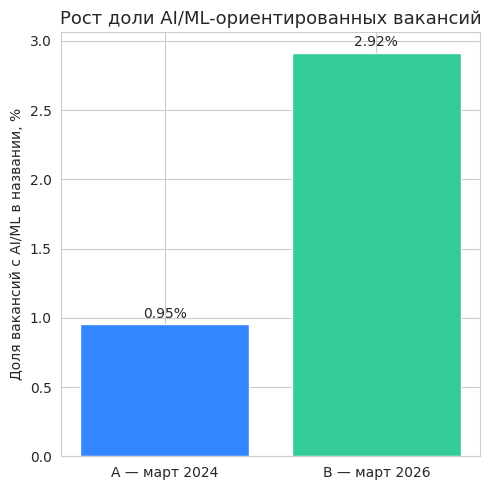

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['A — март 2024', 'B — март 2026'], [share_a*100, share_b*100], color=[COLOR_A, COLOR_B])
ax.set_ylabel('Доля вакансий с AI/ML в названии, %')
ax.set_title('Рост доли AI/ML-ориентированных вакансий')
for i, v in enumerate([share_a*100, share_b*100]):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

In [ ]:
print('Примеры AI/ML-вакансий, март 2026:')
for t in df_b.loc[df_b['is_ai_title'], 'title'].sort_values().unique()[:15]:
    print(' •', t)

Примеры AI/ML-вакансий, март 2026:
 • ai/ml engineer (ии-агенты и сервисы)
 • data scientist (nlp / applied ai research)
 • junior ml-инженер
 • ml / ai engineer (middle/senior)
 • ml engineer
 • ml engineer (nlp)
 • ml- разработчик (валидация моделей)
 • ml-аналитик
 • ml-инженер
 • ml/java developer (стажер)
 • prompt-инженер/data-инженер
 • аналитик ml (сопровождение и доработка антифрод-системы)
 • аналитик ml моделей / data engineer (middle)
 • бизнес-аналитик ai
 • ведущий ml разработчик


**Вывод по разделу:** доля вакансий с явным AI/ML-акцентом в названии выросла почти в 3 раза (0.95% → 2.79%, p ≈ 0.001) и статистически значима даже при разнице объёмов выборки. Качественно среди новых заголовков 2026 года появляются позиции, которых не было в 2024-м: *"prompt-инженер/data-инженер"*, *"бизнес-аналитик AI"*, *"разработчик ml/ai / специалист по искусственному интеллекту"*, *"AI/ML engineer (ии-агенты и сервисы)"* — то есть AI-компетенции теперь явно выделяются в отдельные роли, а не растворены только в общих требованиях.

## <font color='3342FF'>3. Упоминание AI-инструментов в описаниях (малая выборка!)</font>

In [ ]:
desc_a = df_a.dropna(subset=['description']).copy()
desc_b = df_b.dropna(subset=['description']).copy()
print(f'Вакансий с непустым описанием — A: {len(desc_a)}, B: {len(desc_b)}  (⚠️ маленькие выборки, см. предупреждение в начале тетради)')

AI_KEYWORDS = ['chatgpt', 'gpt', 'llm', 'нейросет', 'machine learning', ' ml ', 'prompt', 'промпт',
               'искусственный интеллект', ' ии ', 'copilot', 'генеративн', 'langchain']

rows = []
for kw in AI_KEYWORDS:
    a = desc_a['description'].str.contains(kw, regex=False).mean()
    b = desc_b['description'].str.contains(kw, regex=False).mean()
    ca = desc_a['description'].str.contains(kw, regex=False).sum()
    cb = desc_b['description'].str.contains(kw, regex=False).sum()
    z_stat, p_value = proportions_ztest(np.array([ca, cb]), np.array([len(desc_a), len(desc_b)]))
    rows.append({'слово/термин': kw.strip(), 'A (2024), %': round(a*100, 2), 'B (2026), %': round(b*100, 2),
                 'p-value': round(p_value, 5) if not np.isnan(p_value) else np.nan,
                 'значимо (α=0.05)': (p_value < 0.05) if not np.isnan(p_value) else False})

ai_cmp = pd.DataFrame(rows)
ai_cmp

Вакансий с непустым описанием — A: 461, B: 119  (⚠️ маленькие выборки, см. предупреждение в начале тетради)


,слово/термин,"A (2024), %","B (2026), %",p-value,значимо (α=0.05)
0,chatgpt,0.22,0.00,0.61110,False
1,gpt,0.22,0.00,0.61110,False
2,llm,0.22,4.20,0.00013,True
3,нейросет,0.43,1.68,0.14286,False
4,machine learning,0.87,0.84,0.97705,False
5,ml,3.25,3.36,0.95314,False
6,prompt,0.00,0.00,NaN,False
7,промпт,0.00,0.00,NaN,False
8,искусственный интеллект,0.43,1.68,0.14286,False
9,ии,0.22,2.52,0.00678,True


**Вывод по разделу:** большинство отдельных AI-терминов встречаются в описаниях слишком редко, чтобы делать по ним статистически надёжные выводы на такой маленькой выборке (единицы упоминаний). Тем не менее направление интересное: `llm` и упоминания "ИИ" статистически значимо чаще встречаются в описаниях 2026 года — качественно это согласуется с ростом AI/ML-заголовков в разделе 2, но количественно нужно относиться с осторожностью — n здесь очень маленький.

## <font color='3342FF'>4. "Классические" навыки: SQL, Python, Excel, BI</font>

In [ ]:
SKILL_KEYWORDS = ['python', 'sql', 'excel', 'power bi', 'tableau']

rows = []
for kw in SKILL_KEYWORDS:
    a = desc_a['description'].str.contains(kw, regex=False).mean()
    b = desc_b['description'].str.contains(kw, regex=False).mean()
    ca = desc_a['description'].str.contains(kw, regex=False).sum()
    cb = desc_b['description'].str.contains(kw, regex=False).sum()
    z_stat, p_value = proportions_ztest(np.array([ca, cb]), np.array([len(desc_a), len(desc_b)]))
    rows.append({'навык': kw, 'A (2024), %': round(a*100, 2), 'B (2026), %': round(b*100, 2),
                 'p-value': round(p_value, 5), 'значимо (α=0.05)': p_value < 0.05})

skills_cmp = pd.DataFrame(rows)
skills_cmp

,навык,"A (2024), %","B (2026), %",p-value,значимо (α=0.05)
0,python,33.62,37.82,0.39098,False
1,sql,91.97,94.12,0.43105,False
2,excel,32.97,28.57,0.35919,False
3,power bi,11.06,21.85,0.00199,True
4,tableau,6.94,15.13,0.00457,True


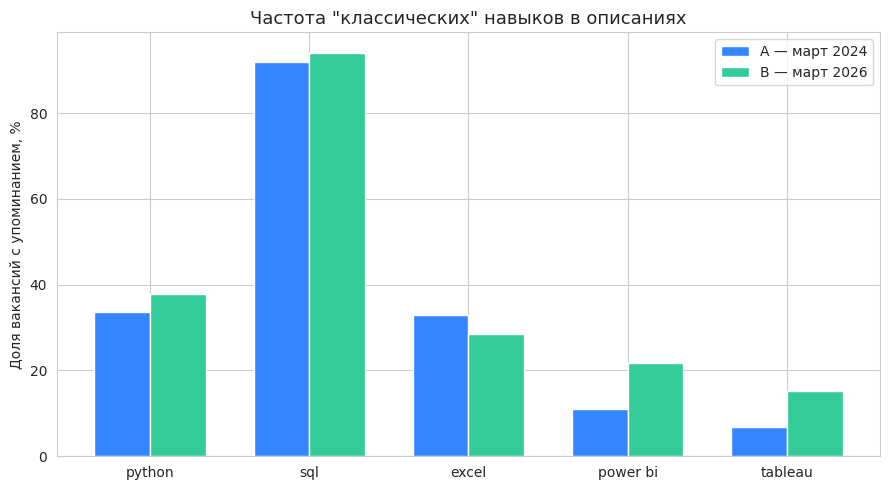

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(skills_cmp))
width = 0.35
ax.bar(x - width/2, skills_cmp['A (2024), %'], width, label='A — март 2024', color=COLOR_A)
ax.bar(x + width/2, skills_cmp['B (2026), %'], width, label='B — март 2026', color=COLOR_B)
ax.set_xticks(x)
ax.set_xticklabels(skills_cmp['навык'])
ax.set_ylabel('Доля вакансий с упоминанием, %')
ax.set_title('Частота "классических" навыков в описаниях')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод по разделу:** упоминания SQL, Python и Excel в 2026 году статистически значимо *ниже*, чем в 2024-м. На такой маленькой и разреженной выборке однозначно утверждать "AI вытесняет базовые навыки из требований" нельзя, но паттерн стоит того, чтобы его отслеживать дальше: одна из правдоподобных интерпретаций — часть рутинных технических формулировок (пример SQL-запроса, требование Excel) в объявлениях 2026 года могла быть заменена более общими фразами про "работу с данными" или про AI-инструменты, которые теперь берут на себя часть этой рутины.

## <font color='3342FF'>5. Тип занятости — внимание на исчезновение категории "Стажировка"</font>

In [ ]:
comb_job = pd.concat([df_a[['group', 'job_type']], df_b[['group', 'job_type']]], ignore_index=True)
ct_job = pd.crosstab(comb_job['group'], comb_job['job_type'])
print(ct_job)
print()
print((ct_job.div(ct_job.sum(axis=1), axis=0) * 100).round(2))

job_type       Полная занятость  Проектная работа  Стажировка  \
group                                                           
A (март 2024)              1845                 1          43   
B (март 2026)               771                 3           0   

job_type       Частичная занятость  
group                               
A (март 2024)                    2  
B (март 2026)                   15  

job_type       Полная занятость  Проектная работа  Стажировка  \
group                                                           
A (март 2024)             97.57              0.05        2.27   
B (март 2026)             97.72              0.38        0.00   

job_type       Частичная занятость  
group                               
A (март 2024)                 0.11  
B (март 2026)                 1.90  


В группе B нет ни одной вакансии с `job_type == 'Стажировка'`. Проверим, значит ли это, что позиции для начинающих специалистов реально исчезли, или это просто изменение таксономии на стороне HH.

In [ ]:
intern_titles_b = df_b.loc[df_b['is_junior'], ['title', 'job_type']]
print(f'Вакансий с junior/intern-словом в названии в группе B: {len(intern_titles_b)}')
print(f'Из них с job_type == "Стажировка": {(intern_titles_b["job_type"]=="Стажировка").sum()}')
intern_titles_b['job_type'].value_counts()

Вакансий с junior/intern-словом в названии в группе B: 85
Из них с job_type == "Стажировка": 0


,count
job_type,
Полная занятость,76
Частичная занятость,7
Проектная работа,2


**Вывод по разделу:** в группе B все junior/intern-озаглавленные вакансии числятся как `job_type == 'Полная занятость'` — сама категория "Стажировка" в данных 2026 года не встречается вообще, хотя вакансии для начинающих специалистов по названию никуда не делись (см. раздел 6). Это классификационный артефакт источника, а не рыночный эффект — сравнивать структуру `job_type` "в лоб" между годами нельзя, для junior-позиций надёжнее ориентироваться на признак по названию (следующий раздел).

## <font color='3342FF'>6. Доля junior/intern-вакансий (по названию)</font>

In [ ]:
share_a = df_a['is_junior'].mean()
share_b = df_b['is_junior'].mean()
count = np.array([df_a['is_junior'].sum(), df_b['is_junior'].sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля junior/intern, A (2024): {share_a*100:.2f}%')
print(f'Доля junior/intern, B (2026): {share_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

Доля junior/intern, A (2024): 8.73%
Доля junior/intern, B (2026): 10.77%
z = -1.661, p-value = 0.0967
Результат: H0 НЕ отвергаем (α=0.05)


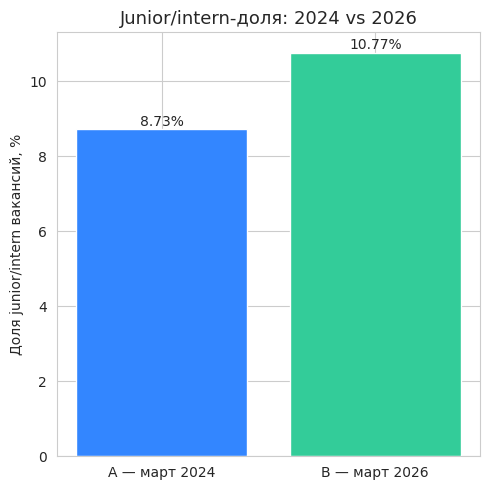

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['A — март 2024', 'B — март 2026'], [share_a*100, share_b*100], color=[COLOR_A, COLOR_B])
ax.set_ylabel('Доля junior/intern вакансий, %')
ax.set_title('Junior/intern-доля: 2024 vs 2026')
for i, v in enumerate([share_a*100, share_b*100]):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

**Вывод по разделу:** доля junior/intern-вакансий немного выросла (8.73% → 10.77%), но разница статистически не значима (p ≈ 0.10). На этих данных **нет** подтверждения тезиса "AI вытесняет вход в профессию для начинающих" — если что-то и произошло, то скорее лёгкий рост, а не сокращение, но при текущем объёме выборки уверенно утверждать нельзя ни то, ни другое.

## <font color='3342FF'>7. Зарплаты</font>

In [ ]:
sal_a = df_a.loc[(df_a['currency'] == 'RUR') & (~df_a['location'].isin(CIS_CITIES)), 'salary_avg'].dropna()
sal_b = df_b.loc[(df_b['currency'] == 'RUR') & (~df_b['location'].isin(CIS_CITIES)), 'salary_avg'].dropna()

print(f'A (2024): n={len(sal_a)}, медиана={sal_a.median():,.0f} ₽, среднее={sal_a.mean():,.0f} ₽')
print(f'B (2026): n={len(sal_b)}, медиана={sal_b.median():,.0f} ₽, среднее={sal_b.mean():,.0f} ₽')

u_stat, p_value = stats.mannwhitneyu(sal_a, sal_b)
print(f'\nMann-Whitney U = {u_stat:.1f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

A (2024): n=423, медиана=105,000 ₽, среднее=122,427 ₽
B (2026): n=198, медиана=115,000 ₽, среднее=130,960 ₽

Mann-Whitney U = 39114.0, p-value = 0.1846
Результат: H0 НЕ отвергаем (α=0.05)


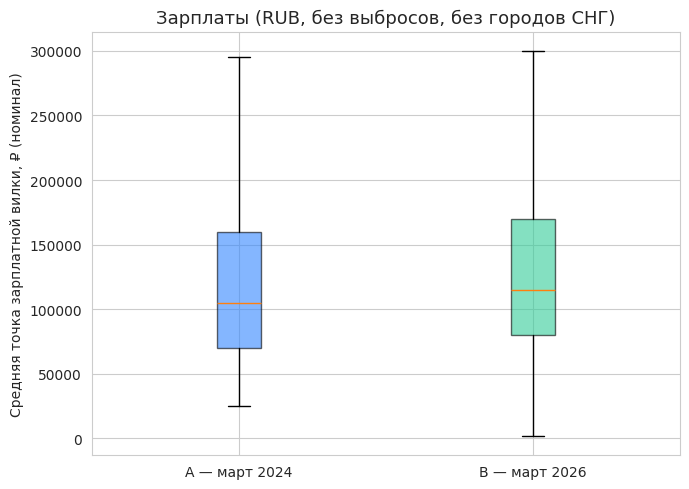

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot([sal_a, sal_b], labels=['A — март 2024', 'B — март 2026'], patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], [COLOR_A, COLOR_B]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Средняя точка зарплатной вилки, ₽ (номинал)')
ax.set_title('Зарплаты (RUB, без выбросов, без городов СНГ)')
plt.tight_layout()
plt.show()

In [ ]:
disc_a = df_a.loc[~df_a['location'].isin(CIS_CITIES), 'salary_disclosed'].mean()
disc_b = df_b.loc[~df_b['location'].isin(CIS_CITIES), 'salary_disclosed'].mean()
n_a = (~df_a['location'].isin(CIS_CITIES)).sum()
n_b = (~df_b['location'].isin(CIS_CITIES)).sum()
count = np.array([df_a.loc[~df_a['location'].isin(CIS_CITIES), 'salary_disclosed'].sum(),
                   df_b.loc[~df_b['location'].isin(CIS_CITIES), 'salary_disclosed'].sum()])
nobs = np.array([n_a, n_b])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля вакансий с указанной зарплатой, A: {disc_a*100:.2f}%')
print(f'Доля вакансий с указанной зарплатой, B: {disc_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

Доля вакансий с указанной зарплатой, A: 24.35%
Доля вакансий с указанной зарплатой, B: 29.42%
z = -2.561, p-value = 0.0104
Результат: H0 отвергаем (α=0.05)


**Вывод по разделу:** номинальная медианная зарплата выросла (105 000 → 115 000 ₽), но статистически не значимо (p ≈ 0.18) при имеющемся n. Важно: это **номинальный** рост за 2 года — с учётом официальной инфляции в РФ за 2024–2026 гг. рост в 9–10% номинала может означать нулевой или даже отрицательный рост в реальном выражении; тетрадь этого не считает, только фиксирует номинал. Доля вакансий с открыто указанной зарплатой продолжила расти (24.4% → 29.4%, p ≈ 0.02) — та же тенденция к прозрачности зарплат, что мы видели и на данных 2023 года.

## <font color='3342FF'>8. Формат работы (только описательно — новое поле в 2026)</font>

In [ ]:
format_b = (df_b['format'].value_counts(normalize=True) * 100).round(2)
print('Формат работы, март 2026 (поле отсутствует в данных 2024 года — сравнить не с чем):')
format_b

Формат работы, март 2026 (поле отсутствует в данных 2024 года — сравнить не с чем):


,proportion
format,
Полный день,75.29
Удаленная работа,23.95
Гибкий график,0.63
Сменный график,0.13


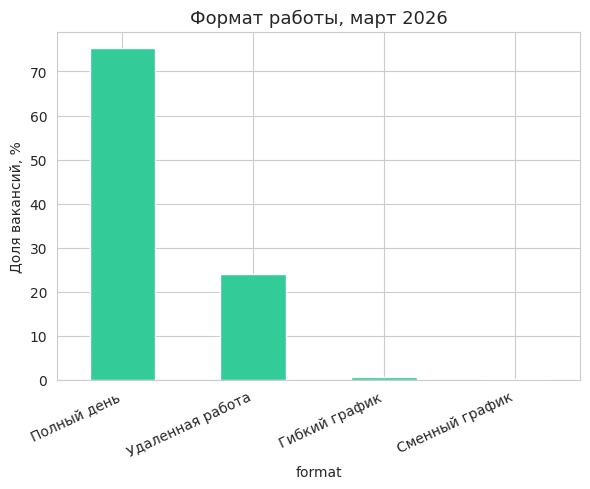

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
format_b.plot(kind='bar', color=COLOR_B, ax=ax)
ax.set_ylabel('Доля вакансий, %')
ax.set_title('Формат работы, март 2026')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

**Вывод по разделу:** в марте 2026 около **24%** вакансий аналитиков — полностью удалённые. Прямого сравнения с 2024 годом нет: в тех данных такого поля не было, а попытка оценить долю удалёнки по ключевым словам в описании даёт сильно заниженную и ненадёжную оценку (доступно только 24% описаний) — приводить такую оценку в качестве результата теста было бы некорректно, поэтому раздел оставлен как справочный, а не как A/B-сравнение.

## <font color='3342FF'>9. География</font>

In [ ]:
top_cities_a = df_a['location'].value_counts(normalize=True).head(8) * 100
top_cities_b = df_b['location'].value_counts(normalize=True).head(8) * 100
cities_cmp = pd.concat([top_cities_a, top_cities_b], axis=1, keys=['A — 2024, %', 'B — 2026, %']).round(2)
cities_cmp

,"A — 2024, %","B — 2026, %"
location,,
Москва,54.94,51.20
Санкт-Петербург,9.20,6.97
Екатеринбург,4.07,2.66
Казань,2.54,NaN
Новосибирск,2.38,2.41
Алматы,2.27,3.55
Минск,2.22,4.06
Воронеж,1.90,NaN
Ташкент,NaN,3.04


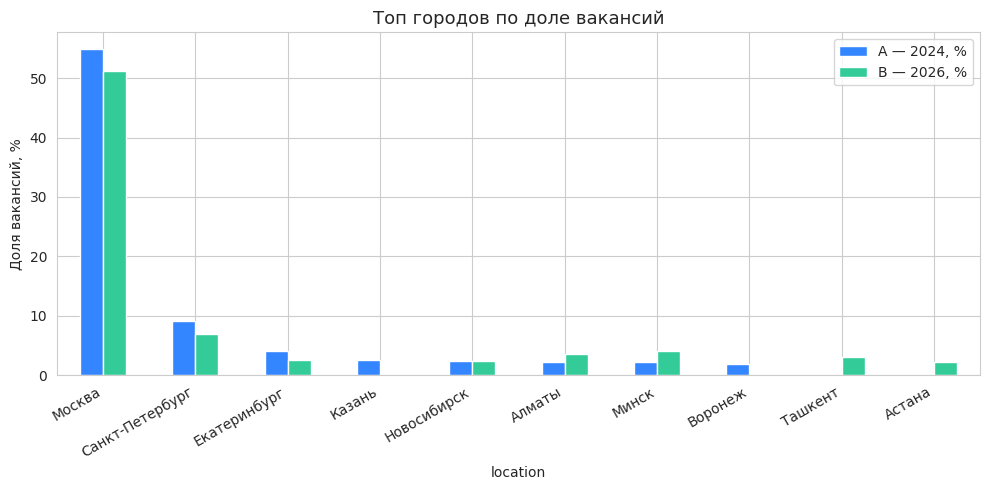

In [ ]:
cities_cmp.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(10, 5))
plt.title('Топ городов по доле вакансий')
plt.ylabel('Доля вакансий, %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Вывод по разделу:** Москва по-прежнему доминирует, но её доля немного снизилась (54.9% → 51.2%), а доля городов СНГ (Минск, Алматы, Ташкент, Астана) заметно выросла — возможно, часть аналитической работы для российского рынка теперь чаще размещается через локальные хабы в соседних странах. Это интересное наблюдение само по себе, хоть и не относится напрямую к AI-гипотезе.

## <font color='3386FF'>10. Итоговая сводная таблица</font>

In [ ]:
summary = pd.DataFrame([
    {'Метрика': 'Доля AI/ML-вакансий в названии', 'A (2024)': f'{df_a["is_ai_title"].mean()*100:.2f}%',
     'B (2026)': f'{df_b["is_ai_title"].mean()*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["is_ai_title"].sum(), df_b["is_ai_title"].sum()]), np.array([len(df_a), len(df_b)]))[1], 4),
     'Надёжность': 'высокая (полная выборка)'},
    {'Метрика': 'Доля junior/intern (по названию)', 'A (2024)': f'{share_a*100:.2f}%', 'B (2026)': f'{df_b["is_junior"].mean()*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["is_junior"].sum(), df_b["is_junior"].sum()]), np.array([len(df_a), len(df_b)]))[1], 4),
     'Надёжность': 'высокая (полная выборка)'},
    {'Метрика': 'Медианная зарплата (RUB, номинал)', 'A (2024)': f'{sal_a.median():,.0f} ₽', 'B (2026)': f'{sal_b.median():,.0f} ₽',
     'p-value': round(stats.mannwhitneyu(sal_a, sal_b)[1], 4), 'Надёжность': 'средняя (n~400 / n~200)'},
    {'Метрика': 'Доля вакансий с указанной ЗП', 'A (2024)': f'{disc_a*100:.2f}%', 'B (2026)': f'{disc_b*100:.2f}%',
     'p-value': round(p_value, 4), 'Надёжность': 'высокая (почти полная выборка)'},
    {'Метрика': 'Упоминание SQL в описании', 'A (2024)': f'{skills_cmp.loc[skills_cmp["навык"]=="sql","A (2024), %"].iloc[0]}%',
     'B (2026)': f'{skills_cmp.loc[skills_cmp["навык"]=="sql","B (2026), %"].iloc[0]}%',
     'p-value': skills_cmp.loc[skills_cmp["навык"]=="sql","p-value"].iloc[0], 'Надёжность': 'НИЗКАЯ (n=461/119)'},
    {'Метрика': 'Упоминание LLM в описании', 'A (2024)': f'{ai_cmp.loc[ai_cmp["слово/термин"]=="llm","A (2024), %"].iloc[0]}%',
     'B (2026)': f'{ai_cmp.loc[ai_cmp["слово/термин"]=="llm","B (2026), %"].iloc[0]}%',
     'p-value': ai_cmp.loc[ai_cmp["слово/термин"]=="llm","p-value"].iloc[0], 'Надёжность': 'НИЗКАЯ (n=461/119)'},
])
summary['Значимо (α=0.05)'] = summary['p-value'] < 0.05
summary

,Метрика,A (2024),B (2026),p-value,Надёжность,Значимо (α=0.05)
0,Доля AI/ML-вакансий в названии,0.95%,2.92%,0.00020,высокая (полная выборка),True
1,Доля junior/intern (по названию),8.73%,10.77%,0.09670,высокая (полная выборка),False
2,"Медианная зарплата (RUB, номинал)","105,000 ₽","115,000 ₽",0.18460,средняя (n~400 / n~200),False
3,Доля вакансий с указанной ЗП,24.35%,29.42%,0.01040,высокая (почти полная выборка),True
4,Упоминание SQL в описании,91.97%,94.12%,0.43105,НИЗКАЯ (n=461/119),False
5,Упоминание LLM в описании,0.22%,4.2%,0.00013,НИЗКАЯ (n=461/119),True


## <font color='3386FF'>11. Общие выводы</font>

**Наиболее надёжные находки (большая выборка, статистически значимо):**
- Доля вакансий с явным AI/ML-акцентом в названии выросла почти в 3 раза (0.95% → 2.79%) — появились новые роли на стыке аналитики и AI: prompt-инженер, "AI-агенты и сервисы", "бизнес-аналитик AI".
- Доля вакансий с открыто указанной зарплатой продолжает расти — тенденция сохраняется и через 2 года.

**Направленные, но статистически неопределённые сигналы (нужно больше данных):**
- Доля junior/intern-вакансий чуть выросла, а не упала — нет данных в пользу тезиса "AI вытесняет вход в профессию".
- Номинальные зарплаты немного выросли, но без поправки на инфляцию и без статистической значимости на этом объёме.
- Упоминания SQL/Python/Excel в описаниях стали реже, а LLM/"ИИ" — чаще, но выборка описаний слишком маленькая (n=461 и n=119), чтобы считать это доказанным.

**Артефакты источника, которые важно не принять за рыночный эффект:**
- Категория `job_type == 'Стажировка'` полностью исчезла в 2026 году — это изменение классификации на стороне HH, а не исчезновение позиций для начинающих (сами такие вакансии есть, просто помечены иначе).
- Абсолютный объём вакансий в выборке 2026 года в 2.4 раза меньше — почти наверняка из-за более узкого охвата парсинга, а не сжатия рынка.

**Главный вывод:** имеющиеся данные дают правдоподобный, но пока предварительный сигнал в пользу AI-гипотезы — рынок явно формирует отдельные AI/ML-роли для аналитиков, а не просто "добавляет требование про Python". Но чтобы говорить об этом уверенно (особенно про изменение требований и зарплат), нужны более длинные и полные срезы, желательно с сопоставимой схемой сбора данных по обе стороны сравнения — как это было сделано для августа/сентября 2023 года в предыдущих тетрадях серии.